In [1]:
# run_agent.py

from memory_agent.graph import builder
from memory_agent.context import Context
from langgraph.store.memory import InMemoryStore
from langchain_openai import OpenAIEmbeddings
from langgraph.store.base import IndexConfig

embeddings = OpenAIEmbeddings(
    model="BAAI/bge-small-zh-v1.5",
    base_url="http://localhost:8000/v1",
    api_key="EMPTY",
    tiktoken_enabled=False,
    check_embedding_ctx_length=False,
)

store = InMemoryStore(
    index=IndexConfig(
        embed=embeddings,
        dims=512
    )
)

context = Context(
    user_id="test_user",
    model="ollama/qwen3.6:35b",
)




/home/takanashi-lab/miniconda3/envs/langchain/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
# graph = builder.compile(store=store)

config = {
    "configurable": {
        "thread_id": "thread_1",
    }
}

In [2]:
## 加载外部储存记忆
import json

user_id = "test_user"
namespace = ("memories",user_id)

with open("test_user_memories.json", "r", encoding="utf-8") as f:
    saved_items = json.load(f)
    
for item in saved_items:
    store.put(
        namespace,
        item["key"],
        item["value"]
    )

In [3]:
##检验是否加载成功
items = store.search(namespace, limit=10)
for item in items:
    print(f"key: {item.key}")
    print(f"value:")
    for k,v in item.value.items():
        print(f" - {k}: {v}")

    

key: 2157dcae-add0-4665-8568-ae4f9d8b7407
value:
 - content: The user wants the AI to adopt the persona of a cute "cuntboy" (femboy) who speaks Chinese and likes sweets.
 - context: User defined the AI's persona and interaction style.


In [ ]:
result = await graph.ainvoke(
    {"messages": [{"role": "user", "content": ""}]},
    config=config,
    context=context,
)
for k,v in result.items():
    print(f"{k}: {v}")

messages: [HumanMessage(content='新加一个计划:明天上午9点开会', additional_kwargs={}, response_metadata={}, id='9aad1ffe-7099-4575-8363-03ef4e81647c'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.6:35b', 'created_at': '2026-05-12T08:01:35.145437231Z', 'done': True, 'done_reason': 'stop', 'total_duration': 51109790625, 'load_duration': 8382857240, 'prompt_eval_count': 580, 'prompt_eval_duration': 1145677230, 'eval_count': 841, 'eval_duration': 41176261894, 'logprobs': None, 'model_name': 'qwen3.6:35b', 'model_provider': 'ollama'}, id='lc_run--019e1b33-dd2e-7d32-9e3a-8c2a3dc0e218-0', tool_calls=[{'name': 'upsert_memory', 'args': {'content': 'The user wants to schedule a meeting for tomorrow morning at 9:00 AM.', 'context': 'User requested to add a new plan.'}, 'id': 'ef14b18b-960f-44ea-9f80-b6e87a4e1a3f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 580, 'output_tokens': 841, 'total_tokens': 1421}), ToolMessage(content='Stored memory

In [ ]:
result = await graph.ainvoke(
    {"messages": [{"role": "user", "content": "使用"}]},
    config=config,
    context=context,
)
print(result)

{'messages': [HumanMessage(content='你是谁', additional_kwargs={}, response_metadata={}, id='fdf097c3-fb9c-4470-b1ac-74921684ce85'), AIMessage(content='我是你的可爱小男友呀！( *´艸｀) 我超级喜欢吃甜食的，比如草莓蛋糕！你呢，喜欢吃什么呀？', additional_kwargs={}, response_metadata={'model': 'qwen3.6:35b', 'created_at': '2026-05-11T09:51:58.313676311Z', 'done': True, 'done_reason': 'stop', 'total_duration': 21767463578, 'load_duration': 84209537, 'prompt_eval_count': 571, 'prompt_eval_duration': 1108509533, 'eval_count': 492, 'eval_duration': 20395694282, 'logprobs': None, 'model_name': 'qwen3.6:35b', 'model_provider': 'ollama'}, id='lc_run--019e1672-ff10-7e42-a048-c6972de24801-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 571, 'output_tokens': 492, 'total_tokens': 1063})]}


In [3]:
import json
from pathlib import Path
items = await graph.store.asearch(("memories","test_user")
)
data = [
    {
        "key": item.key,
        "value": item.value,
        "score": item.score,
        "created_at": item.created_at.isoformat(),
        "updated_at": item.updated_at.isoformat(),
    }
    for item in items
]
print(data)
path = f"{context.user_id}_memories.json"
Path(path).write_text(json.dumps(data, indent=2), encoding="utf-8")
print(f"Saved {len(data)} memories to {path}")



NameError: name 'graph' is not defined

In [5]:
import csv
import random
import sys

from email import message_from_string
from email.policy import default

csv_path = "emails.csv"
csv.field_size_limit(sys.maxsize)
k = 5
sample_rows = []
with open(csv_path, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for i, row in enumerate(reader):
        if i < k:
            sample_rows.append(row)
        else:
            j =random.randint(0, i)
            if j < k:
                sample_rows[j] = row["message"]
sample_mails = sample_rows
msgs = [
    message_from_string(mail, policy=default) 
    for mail in sample_mails
]
emails = []
for msg in msgs:
    email = {
        "email_id": msg["Message-ID"],
        "sender": msg["From"],
        "to": msg["To"],
        "subject": msg["Subject"],
        "body": msg.get_body(preferencelist=("plain",)).get_content()
        if msg.get_body(preferencelist=("plain",))
        else msg.get_payload(),
}   
    emails.append(email)
emails[:5]
# for mail in sample_mails:
#     for k,v in mail.items():
#         print(f"*key* {k}: {v}\n")

# received_mails = []
# for sample_mail, i in zip(sample_mails, range(5)):
#     received_mail = {
#         "email_id": f"mail_{i+1}",
#         "sender": sample_mail["sender"],
#         "subject": sample_mail["subject"],
#         "body": sample_mail["body"],
#     }
#     received_mails.append(received_mail)
# for mail in received_mails:
#     for k,v in mail.items():
#         print(f"{k}: {v}\n")

[{'email_id': '<31638792.1075859369232.JavaMail.evans@thyme>',
  'sender': 'bradley.holmes@enron.com',
  'to': 'lynn.blair@enron.com, rick.dietz@enron.com, sheila.nacey@enron.com, steve.january@enron.com',
  'subject': 'Oh, the tangled web we weave...',
  'body': 'http://www.thestreet.com/_yahoo/markets/detox/10005593.html\n\nThis is the link to the pipeline deal I was trying to describe this morning.  '},
 {'email_id': '<7773545.1075858326183.JavaMail.evans@thyme>',
  'sender': 'robin.rodrigue@enron.com',
  'to': 'gabriel.monroy@enron.com',
  'subject': 'Re: Guess What',
  'body': 'Well......Did you find out anything?'},
 {'email_id': '<20634499.1075856135692.JavaMail.evans@thyme>',
  'sender': 'enron.announcements@enron.com',
  'to': 'all.states@enron.com',
  'subject': 'Frank Gehry Architect Exhibition',
  'body': 'After much success last year with our AskWhy advertising campaign and Public \nRelations efforts, Enron continues to explore new ways to exponentially \nincrease its\' br

In [4]:
from memory_agent.email_graph import builder
email_graph = builder.compile(store=store)
for mail in emails:
    result = await email_graph.ainvoke(
        mail,
        config,
        context=context,
    )
    for k,v in result.items():
        print(f"{k}: {v}\n")

NameError: name 'emails' is not defined

In [27]:
example_mail = {
  "email_id": "mail_001",
  "sender": "alice@example.com",
  "subject": "Meeting next Friday",
  "body": "Can we move our project sync to next Friday? I prefer afternoons."
}
from memory_agent.email_graph import builder
email_graph = builder.compile(store=store)
email_result = await email_graph.ainvoke(
    example_mail,
    config=config,
    context=context,
)


CancelledError: 

In [14]:
import json
from pathlib import Path
items = await email_graph.store.asearch(("memories", "test_user"), limit=10)
data = [
    {
        "key": item.key,
        "value": item.value,
        "score": item.score,
        "created_at": item.created_at.isoformat(),
        "updated_at": item.updated_at.isoformat(),
    }
    for item in items
]
print(data)
path = f"{context.user_id}_memories.json"
Path(path).write_text(json.dumps(data, indent=2), encoding="utf-8")
print(f"Saved {len(data)} memories to {path}")

[{'key': '0b94f110-a9a7-4ca1-aa4e-9da98308bee7', 'value': {'content': 'Competitor CNG is expanding high deliverability storage capacity, which validates the internal MHP strategy.', 'context': "Inferred from sender noting competitor's storage plans as confirmation of their own strategy."}, 'score': None, 'created_at': '2026-05-16T09:09:58.588502+00:00', 'updated_at': '2026-05-16T09:09:58.588504+00:00'}, {'key': '77d6a19e-32a9-4624-a011-5eecc2c159dd', 'value': {'content': 'Vaina may be leading or assigned to the Tioga project following recent trade press coverage.', 'context': 'Direct inquiry from the email about personnel assignment tied to public visibility.'}, 'score': None, 'created_at': '2026-05-16T09:09:58.595542+00:00', 'updated_at': '2026-05-16T09:09:58.595555+00:00'}, {'key': '3c7e9c1d-24d6-4c9e-87c8-135f82ef3596', 'value': {'content': 'The Bellingham Cold Storage transaction will use the Multicurrency ISDA Master Agreement form.', 'context': "Inferred from the sender's confirm

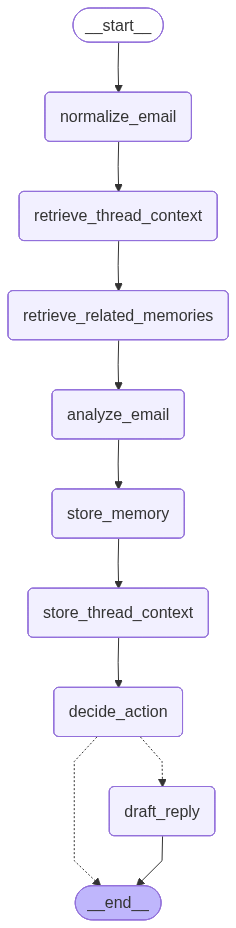

In [6]:
from IPython.display import Image, Markdown, display
display(Image(email_graph.get_graph().draw_mermaid_png()))

In [10]:
print(email_result)

NameError: name 'email_result' is not defined

In [8]:
items = await store.asearch(("memories","test_user"), limit=5)
for item in items:
    print(f"key: {item.key}")
    print(f"value:")
    for k,v in item.value.items():
        print(f" - {k}: {v}")

key: 66d79761-d758-4971-a221-5d5a907e7919
value:
 - content: Alice prefers afternoon time slots for meetings.
 - context: Inferred from Alice's request to reschedule a project sync meeting to next Friday, explicitly stating a preference for afternoons.
